# 🤖 Train XGBoost Model สำหรับ Scalping
รันทีละ Cell จากบนลงล่างได้เลยครับ

## Cell 1 — ติดตั้ง Library (รันครั้งแรกครั้งเดียว)

In [9]:
# ถ้ายังไม่มี ให้ติดตั้งก่อน
# !pip install xgboost scikit-learn yfinance ta joblib pandas numpy
print('✅ พร้อมใช้งาน')
%load_ext autoreload
%autoreload 2

✅ พร้อมใช้งาน
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Cell 2 — Import และดึงข้อมูล

In [10]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import joblib
from src.data_loader import get_processed_data

# ดึงข้อมูลทองคำ กราฟ 5 นาที ย้อนหลัง 60 วัน
# (ใช้ 5m แทน 1m เพื่อให้มีข้อมูลพอ Train)
df = get_processed_data('GC=F', interval='5m', period='60d')
print(f'ข้อมูลทั้งหมด: {len(df)} แถว')
df.tail(3)

[Data] กำลังดึง GC=F | interval=5m | period=60d ...
[Data] ดึงข้อมูลสำเร็จ → 13514 แท่งเทียน
[Feature] กำลังสร้าง Indicators สำหรับ Scalping ...
[Feature] ลบ NaN ออก 33 แถว → เหลือ 13481 แถว
[Pipeline] เสร็จสิ้น → Shape: (13481, 18)
ข้อมูลทั้งหมด: 13481 แถว


,close,high,low,open,volume,returns,log_returns,rsi_7,macd_diff,atr_5,bb_width,bb_position,dist_to_ema9,ema_cross,log_returns_lag_1,log_returns_lag_2,log_returns_lag_3,target
2026-05-26 13:25:00-04:00,4501.399902,4508.899902,4500.700195,4507.000000,8572,-0.001220,-0.001221,34.560036,0.085651,3.709451,0.001403,-0.033690,-0.000735,-1.574311,0.000533,0.000155,-0.000155,0
2026-05-26 13:30:00-04:00,4500.399902,4502.000000,4498.100098,4501.600098,3756,-0.000222,-0.000222,31.968281,-0.116572,3.747541,0.001669,0.004702,-0.000766,-1.901590,-0.001221,0.000533,0.000155,0
2026-05-26 13:35:00-04:00,4497.700195,4501.299805,4495.200195,4500.299805,215,-0.000600,-0.000600,25.860083,-0.390933,4.217955,0.002398,-0.042381,-0.001093,-2.399550,-0.000222,-0.001221,0.000533,0


## Cell 3 — เตรียม X และ y

In [11]:
# Feature ที่ใช้ Train (ต้องตรงกับที่ data_loader สร้าง)
FEATURES = [
    'returns', 'log_returns',
    'rsi_7', 'macd_diff',
    'atr_5', 'bb_width', 'bb_position',
    'dist_to_ema9', 'ema_cross',
    'log_returns_lag_1', 'log_returns_lag_2', 'log_returns_lag_3'
]

X = df[FEATURES]
y = df['target']

print(f'X shape: {X.shape}')
print(f'สัดส่วน Target — ขึ้น: {y.mean()*100:.1f}% | ลง: {(1-y.mean())*100:.1f}%')

X shape: (13481, 12)
สัดส่วน Target — ขึ้น: 49.0% | ลง: 51.0%


## Cell 4 — แบ่ง Train / Test (แบบ Time Series ห้าม Shuffle)

In [12]:
# ใช้ 80% แรกเป็น Train, 20% หลังเป็น Test
# ห้ามใช้ train_test_split แบบ random เพราะข้อมูล Time Series
split = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f'Train: {len(X_train)} แถว')
print(f'Test : {len(X_test)} แถว')

Train: 10784 แถว
Test : 2697 แถว


## Cell 5 — Train XGBoost

In [13]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,       # จำนวนต้นไม้
    max_depth=4,            # ความลึกแต่ละต้น (ลึกไปจะ Overfit)
    learning_rate=0.05,     # ขนาดก้าว (เล็ก=แม่นขึ้น แต่ช้าลง)
    subsample=0.8,          # สุ่มข้อมูล 80% ต่อรอบ
    colsample_bytree=0.8,   # สุ่ม Feature 80% ต่อต้น
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50  # แสดงผลทุก 50 รอบ
)

print('\n✅ Train เสร็จแล้ว!')

[0]	validation_0-logloss:0.69256
[50]	validation_0-logloss:0.69091
[100]	validation_0-logloss:0.69272
[150]	validation_0-logloss:0.69338
[200]	validation_0-logloss:0.69531
[250]	validation_0-logloss:0.69605
[299]	validation_0-logloss:0.69804

✅ Train เสร็จแล้ว!


## Cell 6 — ดูผลลัพธ์

In [14]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f'🎯 Accuracy บน Test Set: {acc*100:.2f}%')
print()
print(classification_report(y_test, y_pred, target_names=['ลง (0)', 'ขึ้น (1)']))

# ถ้า Accuracy > 52% ถือว่าใช้งานได้ครับ
# (ตลาดสุ่ม 50/50 อยู่แล้ว ได้ 52%+ = มี Edge)

🎯 Accuracy บน Test Set: 51.13%

              precision    recall  f1-score   support

      ลง (0)       0.53      0.57      0.55      1408
    ขึ้น (1)       0.49      0.45      0.47      1289

    accuracy                           0.51      2697
   macro avg       0.51      0.51      0.51      2697
weighted avg       0.51      0.51      0.51      2697



## Cell 7 — ดู Feature สำคัญ

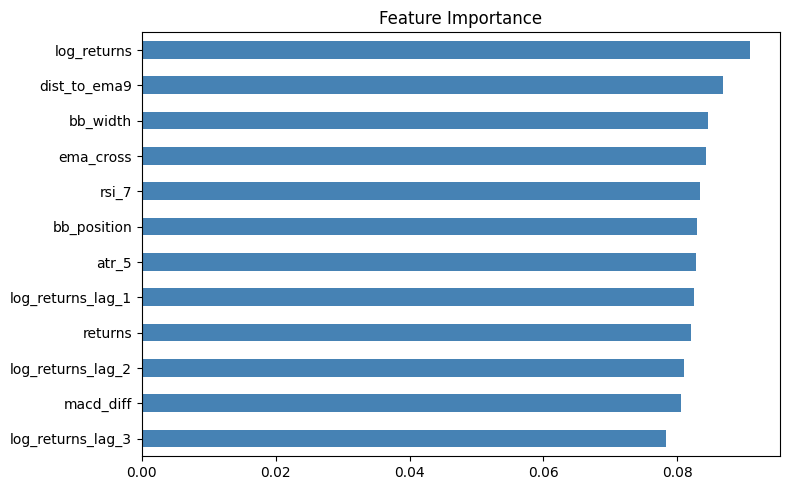


Top 3 Feature สำคัญที่สุด:
log_returns     0.090807
dist_to_ema9    0.086855
bb_width        0.084594
dtype: float32


In [15]:
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=FEATURES)
importance.sort_values().plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

print('\nTop 3 Feature สำคัญที่สุด:')
print(importance.sort_values(ascending=False).head(3))

## Cell 8 — บันทึกโมเดล

In [16]:
import os
import joblib

os.makedirs('models', exist_ok=True)
save_path = 'models/tuned_trading_model.joblib'

joblib.dump(model, save_path)
print(f'✅ บันทึกโมเดลแล้วที่: {save_path}')
print(f'   Feature ที่โมเดลจำ: {model.feature_names_in_.tolist()}')

✅ บันทึกโมเดลแล้วที่: models/tuned_trading_model.joblib
   Feature ที่โมเดลจำ: ['returns', 'log_returns', 'rsi_7', 'macd_diff', 'atr_5', 'bb_width', 'bb_position', 'dist_to_ema9', 'ema_cross', 'log_returns_lag_1', 'log_returns_lag_2', 'log_returns_lag_3']


## ✅ เสร็จแล้ว!
ตอนนี้ `main.py` จะโหลดโมเดลใหม่ได้เลยครับ

---
### ⚠️ ต้อง Re-Train ใหม่เมื่อไหร่?
- ทุก **1-2 สัปดาห์** เพราะตลาด Scalping เปลี่ยนเร็ว
- ถ้าบอทเริ่ม **เสียติดต่อกัน 3-5 ไม้**
- ถ้า Accuracy บน Test Set **ต่ำกว่า 52%**